In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [2]:
transactions = pd.read_csv('data/transactions_train.csv')
customers = pd.read_csv('data/customers.csv')
articles = pd.read_csv('data/articles.csv')

In [3]:
import pandas as pd

# ================================
# Stats USERS
# ================================
print("\n=== MÉTRIQUES USERS ===")

user_interactions = transactions.groupby('customer_id').size()

print(f"Moyenne d'interactions par user: {user_interactions.mean():.2f}")
print(f"Médiane d'interactions par user: {user_interactions.median():.0f}")
print(f"Ratio total: {user_interactions.mean():.2f}")

print(f"\nUsers avec ≤5 interactions: {(user_interactions <= 5).sum()} "
      f"({100 * (user_interactions <= 5).mean():.2f}%)")

print(f"Users avec ≤10 interactions: {(user_interactions <= 10).sum()} "
      f"({100 * (user_interactions <= 10).mean():.2f}%)")

print(f"Users avec >50 interactions: {(user_interactions > 50).sum()} "
      f"({100 * (user_interactions > 50).mean():.2f}%)")

print("\n=== STATISTIQUES DÉTAILLÉES USERS ===")
print(user_interactions.describe())


# ================================
# Stats ITEMS
# ================================
print("\n=== MÉTRIQUES ITEMS ===")

item_interactions = transactions.groupby('article_id').size()

print(f"Moyenne d'interactions par item: {item_interactions.mean():.2f}")
print(f"Médiane d'interactions par item: {item_interactions.median():.0f}")

print("\n=== STATISTIQUES DÉTAILLÉES ITEMS ===")
print(item_interactions.describe())



=== MÉTRIQUES USERS ===
Moyenne d'interactions par user: 23.33
Médiane d'interactions par user: 9
Ratio total: 23.33

Users avec ≤5 interactions: 501358 (36.80%)
Users avec ≤10 interactions: 720499 (52.89%)
Users avec >50 interactions: 171242 (12.57%)

=== STATISTIQUES DÉTAILLÉES USERS ===
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

=== MÉTRIQUES ITEMS ===
Moyenne d'interactions par item: 304.06
Médiane d'interactions par item: 65

=== STATISTIQUES DÉTAILLÉES ITEMS ===
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


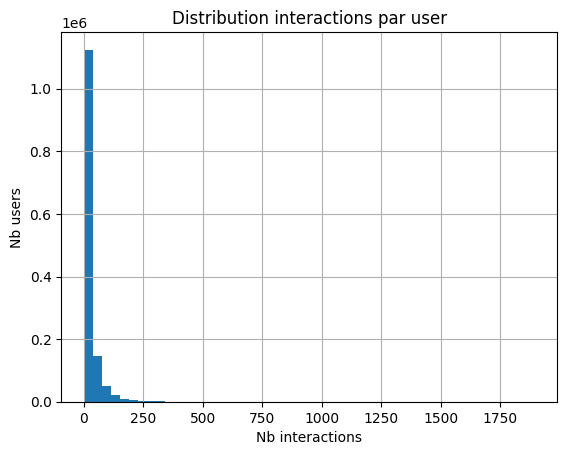

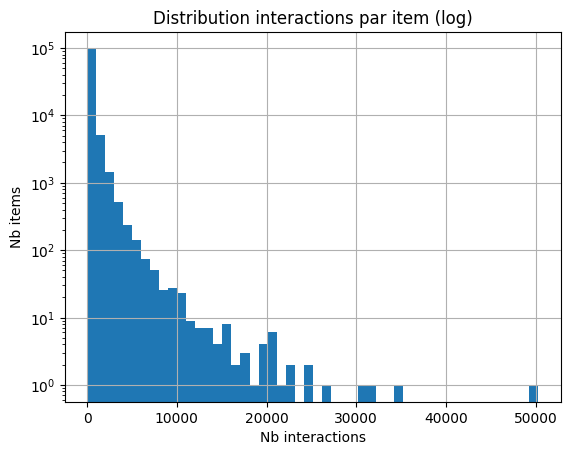

In [4]:
import matplotlib.pyplot as plt

plt.figure()
user_interactions.hist(bins=50)
plt.title("Distribution interactions par user")
plt.xlabel("Nb interactions")
plt.ylabel("Nb users")
plt.show()

plt.figure()
item_interactions.hist(bins=50, log=True)
plt.title("Distribution interactions par item (log)")
plt.xlabel("Nb interactions")
plt.ylabel("Nb items")
plt.show()


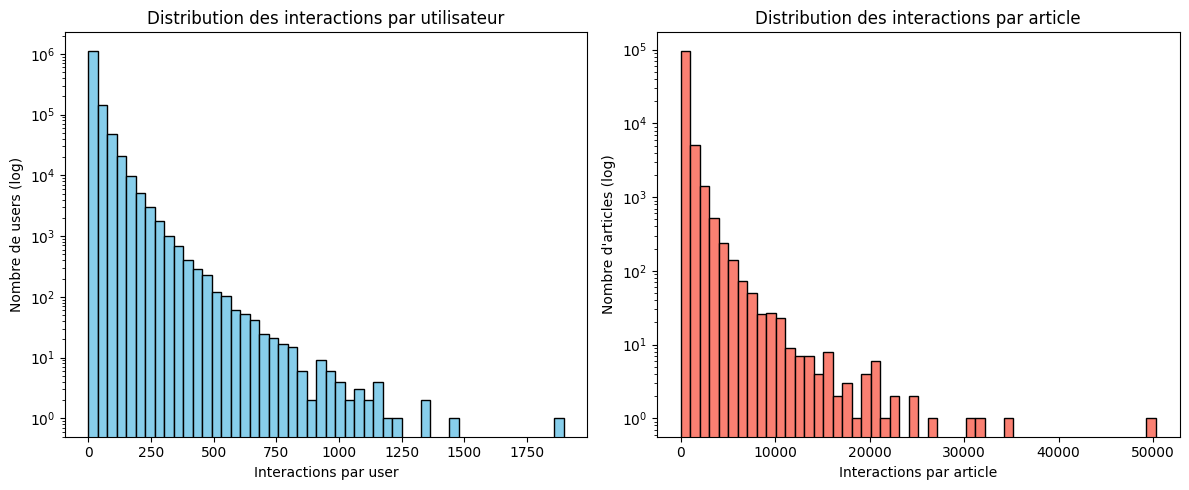

In [7]:
import matplotlib.pyplot as plt

# Comptage interactions
user_counts = transactions.groupby("customer_id").size()
item_counts = transactions.groupby("article_id").size()

# Figure simple
plt.figure(figsize=(12,5))

# Histogramme utilisateurs
plt.subplot(1,2,1)
plt.hist(user_counts, bins=50, color='skyblue', edgecolor='black', log=True)
plt.xlabel("Interactions par user")
plt.ylabel("Nombre de users (log)")
plt.title("Distribution des interactions par utilisateur")

# Histogramme articles
plt.subplot(1,2,2)
plt.hist(item_counts, bins=50, color='salmon', edgecolor='black', log=True)
plt.xlabel("Interactions par article")
plt.ylabel("Nombre d'articles (log)")
plt.title("Distribution des interactions par article")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
user_interactions.hist(bins=50)
plt.title("Distribution interactions par user")
plt.xlabel("Nb interactions")
plt.ylabel("Nb users")
plt.show()

plt.figure()
item_interactions.hist(bins=50, log=True)
plt.title("Distribution interactions par item (log)")
plt.xlabel("Nb interactions")
plt.ylabel("Nb items")
plt.show()


In [5]:
print("Nb transactions :", len(transactions))
print("Nb clients :", transactions['customer_id'].nunique())
print("Nb articles :", transactions['article_id'].nunique())


Nb transactions : 31788324
Nb clients : 1362281
Nb articles : 104547


<Axes: xlabel='t_dat'>

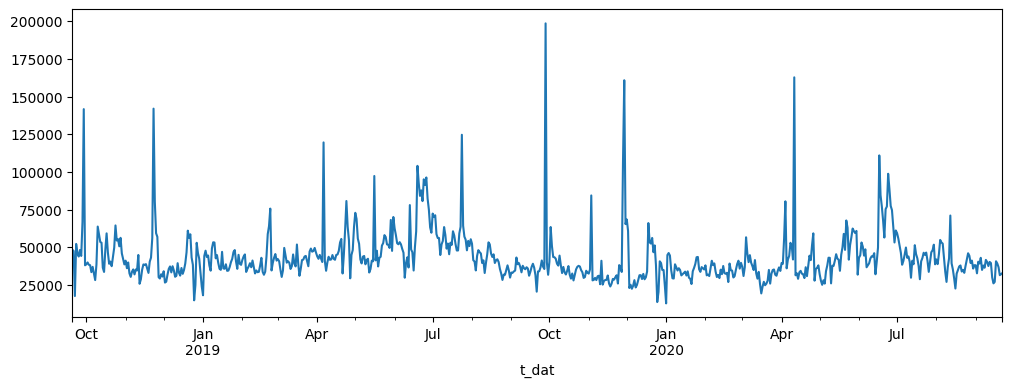

In [6]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['t_dat'].describe()
transactions.groupby('t_dat').size().plot(figsize=(12,4))


In [7]:
client_purchases = transactions.groupby('customer_id').size()

client_purchases.describe()


count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64

<Axes: >

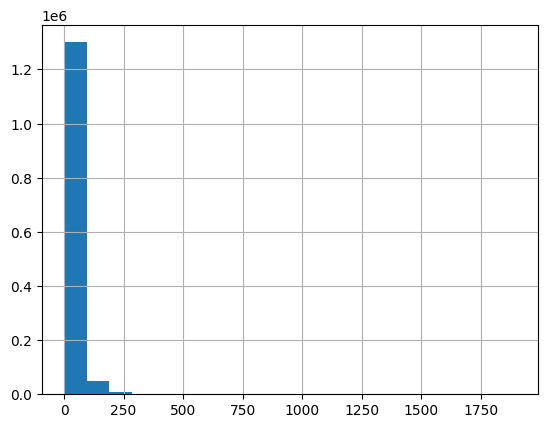

In [8]:
client_purchases.hist(bins=20)


In [9]:
transactions_articles = transactions.merge(
    articles[['article_id', 'product_type_name', 'garment_group_name']],
    on='article_id',
    how='left'
)

In [10]:
transactions_articles['product_type_name'].value_counts().head(10)


product_type_name
Trousers      4217017
Dress         3238428
Sweater       2783274
T-shirt       2203750
Top           1583408
Blouse        1504868
Vest top      1414101
Bra           1335233
Shorts        1152513
Bikini top    1126202
Name: count, dtype: int64

In [11]:
transactions_customers = transactions.merge(
    customers[['customer_id', 'age']],
    on='customer_id',
    how='left'
)


<Axes: xlabel='age'>

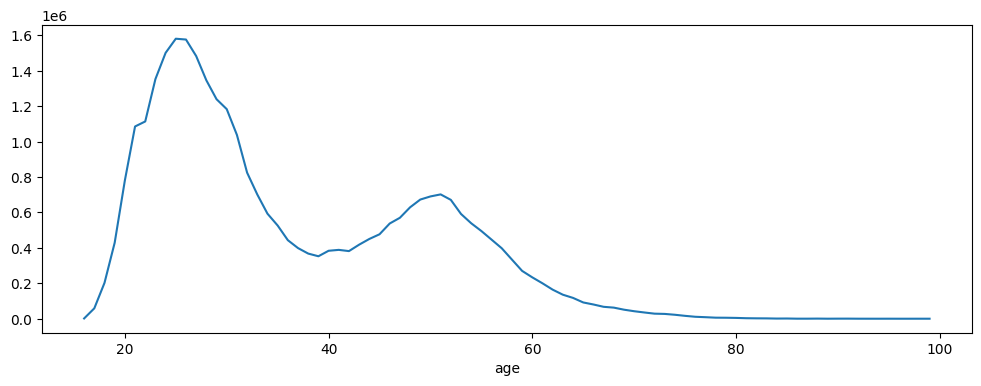

In [12]:
transactions_customers.groupby('age').size().plot(figsize=(12,4))


Missing values:


In [13]:
missing_customers = customers.isna().mean().sort_values(ascending=False)
missing_customers

Active                    0.661508
FN                        0.652378
fashion_news_frequency    0.011670
age                       0.011561
club_member_status        0.004418
customer_id               0.000000
postal_code               0.000000
dtype: float64

In [5]:
trans_cust = transactions.merge(
    customers[['customer_id', 'Active']],
    on='customer_id',
    how='left'
)
# Tous les utilisateurs avec Active = 1
active_users = trans_cust[trans_cust['Active'] == 1]['customer_id'].unique()
# Tous les utilisateurs avec Active = NaN
nan_users = trans_cust[trans_cust['Active'].isna()]['customer_id'].unique()
# Nombre de transactions par utilisateur
trans_per_user = trans_cust.groupby('customer_id').size()
active_trans_per_user = trans_per_user.loc[active_users]
nan_trans_per_user = trans_per_user.loc[nan_users]
print("Active = 1")
print(active_trans_per_user.describe())

print("\nActive = NaN")
print(nan_trans_per_user.describe())


Active = 1
count    460899.000000
mean         29.021230
std          45.962239
min           1.000000
25%           4.000000
50%          13.000000
75%          35.000000
max        1441.000000
dtype: float64

Active = NaN
count    901382.000000
mean         20.426931
std          34.959920
min           1.000000
25%           3.000000
50%           8.000000
75%          23.000000
max        1895.000000
dtype: float64


| Groupe        | Nombre d’utilisateurs | Moyenne transactions | Médiane | 25% | 75% | Min | Max | Conclusion |
|---------------|---------------------|--------------------|---------|-----|-----|-----|-----|------------|
| Active = 1    | 460 899             | 29,0               | 13      | 4   | 35  | 1   | 1441 | Clients actifs avec un nombre de transactions relativement élevé et distribution large. |
| Active = NaN  | 901 382             | 20,4               | 8       | 3   | 23  | 1   | 1895 | Clients généralement peu actifs ; NaN peut être considéré comme Active=0 pour l’analyse. |


In [8]:
# Convertir t_dat en datetime si ce n'est pas déjà fait
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Dernière transaction par utilisateur
last_trans_per_user = trans_cust.groupby('customer_id')['t_dat'].max()
# Active = 1
active_last_trans = last_trans_per_user.loc[active_users]

# Active = NaN
nan_last_trans = last_trans_per_user.loc[nan_users]
print("Active = 1")
print(active_last_trans.describe())

print("\nActive = NaN")
print(nan_last_trans.describe())

Active = 1
count         460899
unique           734
top       2020-09-18
freq            5089
Name: t_dat, dtype: object

Active = NaN
count         901382
unique           734
top       2020-09-19
freq            6283
Name: t_dat, dtype: object


| Groupe        | Nb clients | Nb transactions (moyenne) | Nb transactions (médiane) | Dernière transaction moyenne | Médiane date dernière transaction | Min date | Max date |
|---------------|------------|---------------------------|---------------------------|------------------------------|---------------------------------|----------|----------|
| Active = 1    | 460 899    | 29,0                      | 13                        | 2020-03-06                   | 2020-06-16                      | 2018-09-20 | 2020-09-22 |
| Active = NaN  | 901 382    | 20,4                      | 8                         | 2020-01-12                   | 2020-03-31                      | 2018-09-20 | 2020-09-22 |


In [9]:
# Quartiles
trans_q1 = trans_per_user.quantile(0.5)
date_q1 = last_trans_per_user.quantile(0.5)

print(f"Seuil transactions Q1: {trans_q1}")
print(f"Seuil date dernière transaction Q1: {date_q1}")
# Mask pour NaN
mask_nan = customers['Active'].isna()

# Récupérer transactions et dernière date pour ces clients, alignés avec mask_nan
num_trans_nan = trans_per_user.reindex(customers.loc[mask_nan, 'customer_id']).fillna(0).values
last_trans_nan = last_trans_per_user.reindex(customers.loc[mask_nan, 'customer_id']).fillna(pd.Timestamp.min).values

# Remplacer Active NaN
customers.loc[mask_nan, 'Active'] = ((num_trans_nan > trans_q1) & (last_trans_nan >= date_q1)).astype(int)

# Vérification
customers['Active'].value_counts(dropna=False)



TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [17]:
#FN
customers['FN'] = customers['FN'].fillna(0).astype(int)


In [18]:
missing_transactions = transactions.isna().mean().sort_values(ascending=False)
missing_transactions

t_dat               0.0
customer_id         0.0
article_id          0.0
price               0.0
sales_channel_id    0.0
dtype: float64

In [19]:
missing_articles = articles.isna().mean().sort_values(ascending=False)
missing_articles

detail_desc                     0.003942
perceived_colour_master_name    0.000000
garment_group_name              0.000000
garment_group_no                0.000000
section_name                    0.000000
section_no                      0.000000
index_group_name                0.000000
index_group_no                  0.000000
index_name                      0.000000
index_code                      0.000000
department_name                 0.000000
department_no                   0.000000
article_id                      0.000000
product_code                    0.000000
perceived_colour_value_name     0.000000
perceived_colour_value_id       0.000000
colour_group_name               0.000000
colour_group_code               0.000000
graphical_appearance_name       0.000000
graphical_appearance_no         0.000000
product_group_name              0.000000
product_type_name               0.000000
product_type_no                 0.000000
prod_name                       0.000000
perceived_colour

In [20]:
# --- Features client ---
client_features = transactions.groupby('customer_id').agg(
    num_articles=('article_id','nunique'),
    total_spent=('price','sum'),
    last_purchase=('t_dat','max')
).reset_index()

# --- Features article ---
article_features = transactions.groupby('article_id').agg(
    article_popularity=('customer_id','nunique'),
    price_mean=('price','mean')
).reset_index()

# --- Features client-article ---
client_article_features = transactions.groupby(['customer_id','article_id']).agg(
    num_purchase_client_article=('t_dat','count')
).reset_index()

# Merge seulement les features
data_ml = client_article_features.merge(client_features, on='customer_id', how='left')
data_ml = data_ml.merge(article_features, on='article_id', how='left')

# ===============================
#  CRÉATION DE LA TARGET
# ===============================
split_date = '2020-09-15'
train_df = transactions[transactions['t_dat'] < split_date]
test_df = transactions[transactions['t_dat'] >= split_date]

test_set = test_df[['customer_id','article_id']]
test_set['target'] = 1
data_ml = data_ml.merge(test_set, on=['customer_id','article_id'], how='left')
data_ml['target'] = data_ml['target'].fillna(0).astype(int)

# ===============================
# SÉPARATION TRAIN / VALIDATION
# ===============================
features = ['num_articles','total_spent','article_popularity','price_mean','num_purchase_client_article']
X = data_ml[features]
y = data_ml['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===============================
# ENTRAINEMENT LIGHTGBM
# ===============================
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

model = lgb.train(params, train_data, valid_sets=[train_data,val_data],
                  num_boost_round=500, early_stopping_rounds=50)

# ===============================
#  PRÉDICTIONS
# ===============================
data_ml['pred_prob'] = model.predict(data_ml[features])

# ===============================
#  SOUMISSION KAGGLE
# ===============================
submission = data_ml.groupby('customer_id').apply(
    lambda x: " ".join(x.sort_values('pred_prob', ascending=False).head(12)['article_id'].astype(str))
).reset_index()

submission.columns = ['customer_id','prediction']
submission.to_csv('submission.csv', index=False)



C:\Users\ajarr\AppData\Local\Temp\ipykernel_3852\3057338133.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set['target'] = 1
C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "


[1]	training's auc: 0.73347	valid_1's auc: 0.732929
Training until validation scores don't improve for 50 rounds
[2]	training's auc: 0.742166	valid_1's auc: 0.741468
[3]	training's auc: 0.747814	valid_1's auc: 0.747317
[4]	training's auc: 0.75913	valid_1's auc: 0.758518
[5]	training's auc: 0.760126	valid_1's auc: 0.759341
[6]	training's auc: 0.778879	valid_1's auc: 0.778269
[7]	training's auc: 0.7827	valid_1's auc: 0.782272
[8]	training's auc: 0.784169	valid_1's auc: 0.784049
[9]	training's auc: 0.78449	valid_1's auc: 0.784281
[10]	training's auc: 0.789205	valid_1's auc: 0.789038
[11]	training's auc: 0.790636	valid_1's auc: 0.790567
[12]	training's auc: 0.806758	valid_1's auc: 0.807311
[13]	training's auc: 0.808855	valid_1's auc: 0.809308
[14]	training's auc: 0.810505	valid_1's auc: 0.811023
[15]	training's auc: 0.811715	valid_1's auc: 0.812329
[16]	training's auc: 0.81316	valid_1's auc: 0.813824
[17]	training's auc: 0.814248	valid_1's auc: 0.814791
[18]	training's auc: 0.815171	valid_

KeyboardInterrupt: 

In [21]:
# =========================================================
# PIPELINE LIGHTGBM CORRIGÉ — SANS DATA LEAKAGE
# =========================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
from sklearn.model_selection import GroupShuffleSplit

# -----------------------------
# 1. DATES & SPLIT TEMPOREL
# -----------------------------
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

last_date = transactions['t_dat'].max()
target_start = last_date - pd.Timedelta(weeks=1)
feature_end = target_start   # ⬅️ AUCUNE INFO FUTURE

tx_features = transactions[transactions['t_dat'] < feature_end]
tx_target   = transactions[transactions['t_dat'] >= target_start]

# -----------------------------
# 2. MERGE ARTICLES (FEATURE TIME)
# -----------------------------
tx_features = tx_features.merge(
    articles[['article_id','product_type_name','product_group_name',
              'graphical_appearance_name','colour_group_name',
              'perceived_colour_master_name','department_name','index_name',
              'section_name','garment_group_name']],
    on='article_id', how='left'
)

# -----------------------------
# 3. FEATURES CLIENT (SAFE)
# -----------------------------
client_features = tx_features.groupby('customer_id').agg(
    num_articles=('article_id','nunique'),
    total_spent=('price','sum')
).reset_index()

# -----------------------------
# 4. FEATURES ARTICLE (SAFE)
# -----------------------------
article_features = tx_features.groupby('article_id').agg(
    article_popularity=('customer_id','nunique'),
    price_mean=('price','mean'),
    product_type_name=('product_type_name','first'),
    product_group_name=('product_group_name','first'),
    graphical_appearance_name=('graphical_appearance_name','first'),
    colour_group_name=('colour_group_name','first'),
    perceived_colour_master_name=('perceived_colour_master_name','first'),
    department_name=('department_name','first'),
    index_name=('index_name','first'),
    section_name=('section_name','first'),
    garment_group_name=('garment_group_name','first')
).reset_index()

# -----------------------------
# 5. TARGET = ACHATS DERNIÈRE SEMAINE
# -----------------------------
pos_df = tx_target[['customer_id','article_id']].drop_duplicates()
pos_df['target'] = 1

# -----------------------------
# 6. ÉCHANTILLONNAGE NÉGATIF (SAFE)
# -----------------------------
all_articles = article_features['article_id'].unique()
article_pop = article_features.set_index('article_id')['article_popularity']

negative_samples = []
customers_list = pos_df['customer_id'].unique()

purchased = pos_df.groupby('customer_id')['article_id'].apply(set).to_dict()

for cid in customers_list:
    bought = purchased.get(cid, set())
    candidates = np.setdiff1d(all_articles, list(bought))
    if len(candidates) == 0:
        continue
    sampled = np.random.choice(candidates, size=min(100, len(candidates)), replace=False)
    negative_samples.extend([(cid, art) for art in sampled])

neg_df = pd.DataFrame(negative_samples, columns=['customer_id','article_id'])
neg_df['target'] = 0

# -----------------------------
# 7. MERGE FEATURES
# -----------------------------
data_ml = pd.concat([pos_df, neg_df], ignore_index=True)

data_ml = data_ml.merge(client_features, on='customer_id', how='left')
data_ml = data_ml.merge(article_features, on='article_id', how='left')
data_ml = data_ml.merge(
    customers[['customer_id','FN','Active','club_member_status',
               'fashion_news_frequency','age','postal_code']],
    on='customer_id', how='left'
)

# Nettoyage
data_ml.fillna(0, inplace=True)

# -----------------------------
# 8. FEATURES & TYPES
# -----------------------------
categorical_cols = [
    'product_type_name','product_group_name','graphical_appearance_name',
    'colour_group_name','perceived_colour_master_name','department_name',
    'index_name','section_name','garment_group_name',
    'FN','Active','club_member_status','fashion_news_frequency','postal_code'
]

for col in categorical_cols:
    data_ml[col] = data_ml[col].astype('category')

features = [
    'num_articles','total_spent','article_popularity','price_mean','age'
] + categorical_cols

X = data_ml[features]
y = data_ml['target']
groups = data_ml['customer_id']

# -----------------------------
# 9. SPLIT CORRECT PAR CLIENT
# -----------------------------
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
val_data   = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols)

# -----------------------------
# 10. ENTRAÎNEMENT LIGHTGBM
# -----------------------------
params = {
    'objective':'binary',
    'metric':'auc',
    'learning_rate':0.05,
    'num_leaves':31,
    'verbosity':-1,
    'seed':42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50)]
)

# -----------------------------
# 11. PRÉDICTIONS & SOUMISSION
# -----------------------------
data_ml['pred_prob'] = model.predict(X)

submission = data_ml.groupby('customer_id').apply(
    lambda x: " ".join(
        x.sort_values('pred_prob', ascending=False)
         .head(12)['article_id'].astype(str)
    )
).reset_index()

submission.columns = ['customer_id','prediction']
submission.to_csv('submission.csv', index=False)

gc.collect()

print("✅ Pipeline terminé — sans data leakage")


KeyboardInterrupt: 

In [20]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# -----------------------------
# Transactions récentes
# -----------------------------
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
last_date = transactions['t_dat'].max()
start_date = last_date - pd.Timedelta(weeks=1)

recent_transactions = transactions[(transactions['t_dat'] >= start_date) & 
                                   (transactions['t_dat'] <= last_date)]

# -----------------------------
# Merge avec articles pour avoir toutes les colonnes nécessaires
# -----------------------------
recent_transactions = recent_transactions.merge(
    articles[['article_id','product_type_name','product_group_name',
              'graphical_appearance_name','colour_group_name',
              'perceived_colour_master_name','department_name','index_name',
              'section_name','garment_group_name']],
    on='article_id', how='left'
)

# -----------------------------
# Features client
# -----------------------------
client_features = recent_transactions.groupby('customer_id').agg(
    num_articles=('article_id','nunique'),
    total_spent=('price','sum'),
    last_purchase=('t_dat','max')
).reset_index()

# -----------------------------
#  Features article
# -----------------------------
article_features = recent_transactions.groupby('article_id').agg(
    article_popularity=('customer_id','nunique'),
    price_mean=('price','mean'),
    product_type_name=('product_type_name','first'),
    product_group_name=('product_group_name','first'),
    graphical_appearance_name=('graphical_appearance_name','first'),
    colour_group_name=('colour_group_name','first'),
    perceived_colour_master_name=('perceived_colour_master_name','first'),
    department_name=('department_name','first'),
    index_name=('index_name','first'),
    section_name=('section_name','first'),
    garment_group_name=('garment_group_name','first')
).reset_index()

# -----------------------------
#  Features client-article
# -----------------------------
client_article_features = recent_transactions.groupby(['customer_id','article_id']).agg(
    num_purchase_client_article=('t_dat','count')
).reset_index()

# -----------------------------
#  Définir la target sur la dernière semaine
# -----------------------------
split_date = last_date - pd.Timedelta(weeks=1)
train_df = recent_transactions[recent_transactions['t_dat'] < split_date]
test_df = recent_transactions[recent_transactions['t_dat'] >= split_date]

# Target positif = achats de la dernière semaine
test_set = test_df[['customer_id','article_id']].copy()
test_set['target'] = 1

# -----------------------------
#  Négatifs stratifiés - Optimisé
# -----------------------------
all_articles = article_features['article_id'].unique()  # ← Correction ici
article_popularity = recent_transactions.groupby('article_id', observed=True)['customer_id'].nunique()
article_popularity = (article_popularity / article_popularity.sum()).astype(np.float32)

# Preallouer la liste pour améliorer performance
unique_customers = client_features['customer_id'].unique()
n_customers = len(unique_customers)
negative_samples = []

# Optimisation: utiliser un dictionnaire pour accès rapide
purchased_by_customer = test_set.groupby('customer_id', observed=True)['article_id'].apply(set).to_dict()
article_to_category = article_features.set_index('article_id')['product_group_name'].to_dict()

for cid in unique_customers:
    purchased_articles = purchased_by_customer.get(cid, set())
    purchased_categories = {article_to_category.get(art) for art in purchased_articles if art in article_to_category}
    not_purchased = np.setdiff1d(all_articles, list(purchased_articles))
    
    if len(not_purchased) == 0:
        continue
    
    # 50% populaires
    pop_candidates = not_purchased
    valid_pop = np.intersect1d(pop_candidates, article_popularity.index)
    if len(valid_pop) > 0:
        probs = article_popularity.loc[valid_pop].values
        probs = probs / probs.sum()
        n_pop = int(100 * 0.5)
        pop_sampled = np.random.choice(valid_pop, size=min(n_pop, len(valid_pop)), replace=False, p=probs)
    else:
        pop_sampled = np.array([])
    
    # 30% même catégorie
    cat_candidates = [art for art in not_purchased if article_to_category.get(art) in purchased_categories]
    n_cat = int(100 * 0.3)
    cat_sampled = np.random.choice(cat_candidates, size=min(n_cat, len(cat_candidates)), replace=False) if len(cat_candidates) > 0 else np.array([])
    
    # 20% au hasard
    remaining_candidates = np.setdiff1d(not_purchased, np.concatenate([pop_sampled, cat_sampled]))
    n_rand = 100 - len(pop_sampled) - len(cat_sampled)
    rand_sampled = np.random.choice(remaining_candidates, size=min(n_rand, len(remaining_candidates)), replace=False) if len(remaining_candidates) > 0 else np.array([])
    
    sampled = np.concatenate([pop_sampled, cat_sampled, rand_sampled])
    negative_samples.extend([(cid, art) for art in sampled])

# Libérer mémoire
del purchased_by_customer, article_to_category
gc.collect()

neg_df = pd.DataFrame(negative_samples, columns=['customer_id', 'article_id'])
neg_df['target'] = np.int8(0)

# Pas besoin de reconvertir en category ici, ça se fera naturellement au merge
# Merge features
neg_df = neg_df.merge(client_features, on='customer_id', how='left')
neg_df = neg_df.merge(article_features, on='article_id', how='left')


# -----------------------------
# Combiner positifs + négatifs
# -----------------------------
pos_df = test_set.merge(client_features, on='customer_id', how='left') \
                 .merge(article_features, on='article_id', how='left') \
                 .merge(client_article_features, on=['customer_id', 'article_id'], how='left')

# Pour les négatifs, merger aussi client_article_features
neg_df = neg_df.merge(client_article_features, on=['customer_id', 'article_id'], how='left')

data_ml = pd.concat([pos_df, neg_df], ignore_index=True)

# Remplir les NaN de num_purchase_client_article par 0 (pas d'achat précédent)
data_ml['num_purchase_client_article'] = data_ml['num_purchase_client_article'].fillna(0).astype(np.int16)

# Libérer mémoire
del pos_df, neg_df, test_set
gc.collect()


# -----------------------------
# Ajouter métadonnées clients
# -----------------------------
data_ml = data_ml.merge(customers[['customer_id','FN','Active','club_member_status',
                                   'fashion_news_frequency','age','postal_code']], 
                        on='customer_id', how='left')



categorical_cols = ['product_type_name', 'product_group_name',
                    'graphical_appearance_name', 'colour_group_name', 
                    'perceived_colour_master_name', 'department_name', 
                    'index_name', 'section_name', 'garment_group_name',
                    'FN', 'Active', 'club_member_status', 
                    'fashion_news_frequency', 'postal_code']
for col in categorical_cols:
    data_ml[col] = data_ml[col].astype('category')
# Liste des features
features = ['num_articles', 'total_spent', 'article_popularity', 'price_mean',
            'num_purchase_client_article', 'age'] + categorical_cols
# -----------------------------
#  Préparer train / validation
# -----------------------------
features = ['num_articles','total_spent','article_popularity','price_mean',
            'num_purchase_client_article','age'] + categorical_cols
X = data_ml[features]
y = data_ml['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols)

# -----------------------------
#  Entraînement LightGBM
# -----------------------------
params = {
    'objective':'binary',
    'metric':'auc',
    'boosting_type':'gbdt',
    'learning_rate':0.05,
    'num_leaves':31,
    'scale_pos_weight': y_train.value_counts()[0]/y_train.value_counts()[1],
    'verbose':-1
}

model = lgb.train(params, train_data, valid_sets=[train_data,val_data],
                  num_boost_round=500, early_stopping_rounds=50)

# -----------------------------
#  Prédictions
# -----------------------------
data_ml['pred_prob'] = model.predict(X)

# -----------------------------
# Préparer soumission Kaggle
# -----------------------------
submission = data_ml.groupby('customer_id').apply(
    lambda x: " ".join(x.sort_values('pred_prob', ascending=False).head(12)['article_id'].astype(str))
).reset_index()

submission.columns = ['customer_id','prediction']
submission.to_csv('submission.csv', index=False)

C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters f

[1]	training's auc: 1	valid_1's auc: 1
Training until validation scores don't improve for 50 rounds
[2]	training's auc: 1	valid_1's auc: 1
[3]	training's auc: 1	valid_1's auc: 1
[4]	training's auc: 1	valid_1's auc: 1
[5]	training's auc: 1	valid_1's auc: 1
[6]	training's auc: 1	valid_1's auc: 1
[7]	training's auc: 1	valid_1's auc: 1
[8]	training's auc: 1	valid_1's auc: 1
[9]	training's auc: 1	valid_1's auc: 1
[10]	training's auc: 1	valid_1's auc: 1
[11]	training's auc: 1	valid_1's auc: 1
[12]	training's auc: 1	valid_1's auc: 1
[13]	training's auc: 1	valid_1's auc: 1
[14]	training's auc: 1	valid_1's auc: 1
[15]	training's auc: 1	valid_1's auc: 1
[16]	training's auc: 1	valid_1's auc: 1
[17]	training's auc: 1	valid_1's auc: 1
[18]	training's auc: 1	valid_1's auc: 1
[19]	training's auc: 1	valid_1's auc: 1
[20]	training's auc: 1	valid_1's auc: 1
[21]	training's auc: 1	valid_1's auc: 1
[22]	training's auc: 1	valid_1's auc: 1
[23]	training's auc: 1	valid_1's auc: 1
[24]	training's auc: 1	valid

C:\Users\ajarr\AppData\Local\Temp\ipykernel_9392\3921679794.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  submission = data_ml.groupby('customer_id').apply(


In [ ]:
data_ml[categorical_cols].dtypes

product_type_name               category
product_group_name              category
graphical_appearance_name       category
colour_group_name               category
perceived_colour_master_name    category
department_name                 category
index_name                      category
section_name                    category
garment_group_name              category
FN                              category
Active                          category
club_member_status              category
fashion_news_frequency          category
postal_code                     category
dtype: object

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import gc

# -----------------------------
# 0️⃣ Fonction d'optimisation mémoire
# -----------------------------
def optimize_dtypes(df):
    """Optimise les types de données pour réduire la mémoire"""
    for col in df.columns:
        col_type = df[col].dtype
        
        # Ne traiter QUE les colonnes numériques (int et float)
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
            
        c_min = df[col].min()
        c_max = df[col].max()
        
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type)[:5] == 'float':
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    return df



# -----------------------------
# 1️⃣ Transactions récentes - Optimisé
# -----------------------------
# Convertir en datetime avec format spécifique (plus rapide)
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], format='%Y-%m-%d')
last_date = transactions['t_dat'].max()
start_date = last_date - pd.Timedelta(weeks=4)

# Filtrer directement
recent_transactions = transactions[
    (transactions['t_dat'] >= start_date) & 
    (transactions['t_dat'] <= last_date)
].copy()

# Libérer mémoire si transactions n'est plus nécessaire
# del transactions
# gc.collect()

# Optimiser les types
recent_transactions = optimize_dtypes(recent_transactions)

# Convertir article_id et customer_id en category si pertinent
recent_transactions['article_id'] = recent_transactions['article_id'].astype('category')
recent_transactions['customer_id'] = recent_transactions['customer_id'].astype('category')

# -----------------------------
# 2️⃣ Merge - Optimisé
# -----------------------------
# Convertir les colonnes catégorielles des articles AVANT le merge
cat_cols_articles = ['product_type_name', 'product_group_name',
                     'graphical_appearance_name', 'colour_group_name',
                     'perceived_colour_master_name', 'department_name',
                     'index_name', 'section_name', 'garment_group_name']

for col in cat_cols_articles:
    if col in articles.columns:
        articles[col] = articles[col].astype('category')

articles['article_id'] = articles['article_id'].astype('category')

recent_transactions = recent_transactions.merge(
    articles[['article_id'] + cat_cols_articles],
    on='article_id', how='left'
)

# -----------------------------
# 3️⃣ Features client - Optimisé
# -----------------------------
client_features = recent_transactions.groupby('customer_id', observed=True).agg(
    num_articles=('article_id', 'nunique'),
    total_spent=('price', 'sum'),
    last_purchase=('t_dat', 'max')
).reset_index()

client_features = optimize_dtypes(client_features)

# -----------------------------
# 4️⃣ Features article - Optimisé
# -----------------------------
article_features = recent_transactions.groupby('article_id', observed=True).agg(
    article_popularity=('customer_id', 'nunique'),
    price_mean=('price', 'mean'),
    product_type_name=('product_type_name', 'first'),
    product_group_name=('product_group_name', 'first'),
    graphical_appearance_name=('graphical_appearance_name', 'first'),
    colour_group_name=('colour_group_name', 'first'),
    perceived_colour_master_name=('perceived_colour_master_name', 'first'),
    department_name=('department_name', 'first'),
    index_name=('index_name', 'first'),
    section_name=('section_name', 'first'),
    garment_group_name=('garment_group_name', 'first')
).reset_index()

article_features = optimize_dtypes(article_features)

# -----------------------------
# 5️⃣ Features client-article - Optimisé
# -----------------------------
client_article_features = recent_transactions.groupby(
    ['customer_id', 'article_id'], observed=True
)['t_dat'].count().reset_index(name='num_purchase_client_article')

client_article_features = optimize_dtypes(client_article_features)

# -----------------------------
# 6️⃣ Split train/test - Optimisé
# -----------------------------
split_date = last_date - pd.Timedelta(weeks=1)

# Utiliser des masques booléens (plus efficace)
mask_train = recent_transactions['t_dat'] < split_date
mask_test = ~mask_train

test_set = recent_transactions.loc[mask_test, ['customer_id', 'article_id']].copy()
test_set['target'] = np.int8(1)  # int8 au lieu de int par défaut

# Libérer mémoire
del mask_train, mask_test
gc.collect()

# -----------------------------
# 7️⃣ Négatifs stratifiés - Optimisé
# -----------------------------
all_articles = article_features['article_id'].cat.categories.values
article_popularity = recent_transactions.groupby('article_id', observed=True)['customer_id'].nunique()
article_popularity = (article_popularity / article_popularity.sum()).astype(np.float32)

# Preallouer la liste pour améliorer performance
unique_customers = client_features['customer_id'].unique()
n_customers = len(unique_customers)
negative_samples = []

# Optimisation: utiliser un dictionnaire pour accès rapide
purchased_by_customer = test_set.groupby('customer_id', observed=True)['article_id'].apply(set).to_dict()
article_to_category = article_features.set_index('article_id')['product_group_name'].to_dict()

for cid in unique_customers:
    purchased_articles = purchased_by_customer.get(cid, set())
    purchased_categories = {article_to_category.get(art) for art in purchased_articles if art in article_to_category}
    not_purchased = np.setdiff1d(all_articles, list(purchased_articles))
    
    if len(not_purchased) == 0:
        continue
    
    # 50% populaires
    pop_candidates = not_purchased
    valid_pop = np.intersect1d(pop_candidates, article_popularity.index)
    if len(valid_pop) > 0:
        probs = article_popularity.loc[valid_pop].values
        probs = probs / probs.sum()
        n_pop = int(100 * 0.5)
        pop_sampled = np.random.choice(valid_pop, size=min(n_pop, len(valid_pop)), replace=False, p=probs)
    else:
        pop_sampled = np.array([])
    
    # 30% même catégorie
    cat_candidates = [art for art in not_purchased if article_to_category.get(art) in purchased_categories]
    n_cat = int(100 * 0.3)
    cat_sampled = np.random.choice(cat_candidates, size=min(n_cat, len(cat_candidates)), replace=False) if len(cat_candidates) > 0 else np.array([])
    
    # 20% au hasard
    remaining_candidates = np.setdiff1d(not_purchased, np.concatenate([pop_sampled, cat_sampled]))
    n_rand = 100 - len(pop_sampled) - len(cat_sampled)
    rand_sampled = np.random.choice(remaining_candidates, size=min(n_rand, len(remaining_candidates)), replace=False) if len(remaining_candidates) > 0 else np.array([])
    
    sampled = np.concatenate([pop_sampled, cat_sampled, rand_sampled])
    negative_samples.extend([(cid, art) for art in sampled])

# Libérer mémoire
del purchased_by_customer, article_to_category
gc.collect()

neg_df = pd.DataFrame(negative_samples, columns=['customer_id', 'article_id'])
neg_df['target'] = np.int8(0)
neg_df['customer_id'] = neg_df['customer_id'].astype('category')
neg_df['article_id'] = neg_df['article_id'].astype('category')

# Merge features
neg_df = neg_df.merge(client_features, on='customer_id', how='left')
neg_df = neg_df.merge(article_features, on='article_id', how='left')

# -----------------------------
# 8️⃣ Combiner positifs + négatifs
# -----------------------------
pos_df = test_set.merge(client_features, on='customer_id', how='left').merge(article_features, on='article_id', how='left')
data_ml = pd.concat([pos_df, neg_df], ignore_index=True)

# Libérer mémoire
del pos_df, neg_df, test_set
gc.collect()

# -----------------------------
# 9️⃣ Métadonnées clients - Optimisé
# -----------------------------
# Convertir en category AVANT le merge
customer_cat_cols = ['FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'postal_code']
for col in customer_cat_cols:
    if col in customers.columns:
        customers[col] = customers[col].astype('category')

customers['customer_id'] = customers['customer_id'].astype('category')
customers['age'] = customers['age'].astype(np.float32)

data_ml = data_ml.merge(
    customers[['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']], 
    on='customer_id', how='left'
)

# Optimiser data_ml
data_ml = optimize_dtypes(data_ml)

# Catégorielles finales
categorical_cols = ['product_type_name', 'product_group_name',
                    'graphical_appearance_name', 'colour_group_name', 
                    'perceived_colour_master_name', 'department_name', 
                    'index_name', 'section_name', 'garment_group_name',
                    'FN', 'Active', 'club_member_status', 
                    'fashion_news_frequency', 'postal_code']

# -----------------------------
# 10️⃣ Préparer train/val - Optimisé
# -----------------------------
features = ['num_articles', 'total_spent', 'article_popularity', 'price_mean',
            'num_purchase_client_article', 'age'] + categorical_cols

X = data_ml[features]
y = data_ml['target'].astype(np.int8)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Paramètres LightGBM optimisés pour mémoire
train_data = lgb.Dataset(
    X_train, label=y_train, 
    categorical_feature=categorical_cols,
    free_raw_data=True  # Libère les données brutes après construction
)
val_data = lgb.Dataset(
    X_val, label=y_val, 
    categorical_feature=categorical_cols,
    reference=train_data,
    free_raw_data=True
)

# Libérer mémoire
del X_train, X_val
gc.collect()

# -----------------------------
# 11️⃣ Entraînement LightGBM - Optimisé
# -----------------------------
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_bin': 255,  # Réduit la mémoire (défaut=255)
    'scale_pos_weight': y_train.value_counts()[0] / y_train.value_counts()[1],
    'verbose': -1,
    'min_data_in_leaf': 20,  # Réduit mémoire du modèle
    'feature_fraction': 0.8,  # Utilise moins de features par arbre
    'bagging_fraction': 0.8,  # Sous-échantillonne les données
    'bagging_freq': 5
}

model = lgb.train(
    params, train_data, 
    valid_sets=[val_data],  # Seulement validation (pas train_data)
    num_boost_round=500, 
    callbacks=[lgb.early_stopping(50)]
)

# -----------------------------
# 12️⃣ Prédictions
# -----------------------------
data_ml['pred_prob'] = model.predict(X, num_threads=-1).astype(np.float32)

# -----------------------------
# 13️⃣ Soumission Kaggle
# -----------------------------
submission = data_ml.groupby('customer_id', observed=True).apply(
    lambda x: " ".join(x.nlargest(12, 'pred_prob')['article_id'].astype(str)),
    include_groups=False
).reset_index()

submission.columns = ['customer_id', 'prediction']
submission.to_csv('submission.csv', index=False)

print(f"Mémoire totale utilisée: {data_ml.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


AttributeError: Can only use .cat accessor with a 'category' dtype

In [21]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
import implicit
from tqdm import tqdm

# ============================================================
# 1) SPLIT TEMPOREL (5 semaines train / 1 semaine test)
# ============================================================
MAX_DATE = transactions["t_dat"].max()

TEST_START  = MAX_DATE - pd.Timedelta(days=7)
TRAIN_START = MAX_DATE - pd.Timedelta(days=42)

df_train = transactions[
    (transactions["t_dat"] >= TRAIN_START) &
    (transactions["t_dat"] < TEST_START)
].copy()

df_test = transactions[
    transactions["t_dat"] >= TEST_START
].copy()

print(f"Train transactions: {len(df_train):,}")
print(f"Test transactions : {len(df_test):,}")

# ============================================================
# 2) MAPPING USERS / ITEMS (UNIQUEMENT TRAIN)
# ============================================================
TRAIN_USERS = df_train["customer_id"].unique()
TRAIN_ITEMS = df_train["article_id"].unique()

user_map = {u: i for i, u in enumerate(TRAIN_USERS)}
item_map = {a: j for j, a in enumerate(TRAIN_ITEMS)}

df_train["user_id"] = df_train["customer_id"].map(user_map)
df_train["item_id"] = df_train["article_id"].map(item_map)

df_test["user_id"] = df_test["customer_id"].map(user_map)
df_test["item_id"] = df_test["article_id"].map(item_map)

df_train = df_train.dropna(subset=["user_id", "item_id"])
df_test  = df_test.dropna(subset=["user_id", "item_id"])

df_train["user_id"] = df_train["user_id"].astype(np.int32)
df_train["item_id"] = df_train["item_id"].astype(np.int32)
df_test["user_id"]  = df_test["user_id"].astype(np.int32)
df_test["item_id"]  = df_test["item_id"].astype(np.int32)

n_users = len(TRAIN_USERS)
n_items = len(TRAIN_ITEMS)

print(f"Users: {n_users:,} | Items: {n_items:,}")

# ============================================================
# 3) MATRICES SPARSE (PONDÉRATION DE RÉCENCE)
# ============================================================
def build_sparse_matrix(df, n_users, n_items, use_recency=True):
    if use_recency:
        max_date = df["t_dat"].max()
        days_ago = (max_date - df["t_dat"]).dt.days
        data = np.exp(-days_ago / 7.0).astype(np.float32)
    else:
        data = np.ones(len(df), dtype=np.float32)

    rows = df["user_id"].values
    cols = df["item_id"].values

    return coo_matrix((data, (rows, cols)), shape=(n_users, n_items))

coo_train = build_sparse_matrix(df_train, n_users, n_items, True)
coo_test  = build_sparse_matrix(df_test,  n_users, n_items, False)

csr_train = coo_train.tocsr()
csr_test  = coo_test.tocsr()

# ============================================================
# 4) ENTRAÎNEMENT ALS
# ============================================================
model = implicit.als.AlternatingLeastSquares(
    factors=200,
    iterations=15,
    regularization=0.01,
    alpha=15.0,
    random_state=42
)

print("\nTraining ALS...")
model.fit(csr_train, show_progress=True)

# ============================================================
# 5) MAP@12 MANUEL (ROBUSTE, SANS BUG)
# ============================================================
def apk(actual, predicted, k=12):
    if len(actual) == 0:
        return 0.0

    score = 0.0
    hits = 0

    for i, p in enumerate(predicted[:k]):
        if p in actual:
            hits += 1
            score += hits / (i + 1)

    return score / min(len(actual), k)

def mapk(model, train_csr, test_csr, k=12):
    test_users = np.where(test_csr.getnnz(axis=1) > 0)[0]
    print(f"\nÉvaluation sur {len(test_users):,} users")

    ap_scores = []

    for u in tqdm(test_users):
        s, e = test_csr.indptr[u], test_csr.indptr[u + 1]
        actual_items = set(test_csr.indices[s:e])

        recs, _ = model.recommend(
            userid=u,
            user_items=train_csr[u],
            N=k,
            filter_already_liked_items=True
        )

        ap_scores.append(apk(actual_items, recs, k))

    return float(np.mean(ap_scores))

map12 = mapk(model, csr_train, csr_test, k=12)

print(f"\n{'='*60}")
print(f"MAP@12 (5 semaines train / 1 semaine test) = {map12:.5f}")
print(f"{'='*60}")

# ============================================================
# 6) BASELINE POPULARITÉ
# ============================================================
def popularity_baseline(train_df, test_csr, k=12):
    top_items = train_df["item_id"].value_counts().head(k).index.tolist()
    test_users = np.where(test_csr.getnnz(axis=1) > 0)[0]

    scores = []
    for u in test_users:
        s, e = test_csr.indptr[u], test_csr.indptr[u + 1]
        actual = set(test_csr.indices[s:e])
        scores.append(apk(actual, top_items, k))

    return float(np.mean(scores))

baseline_map = popularity_baseline(df_train, csr_test)
print(f"Baseline popularity MAP@12 = {baseline_map:.5f}")

# ============================================================
# 7) VISUALISATION DES 12 ARTICLES RECOMMANDÉS
# ============================================================
reverse_item_map = {v: k for k, v in item_map.items()}

sample_users = [u for u in range(n_users) if csr_train[u].getnnz() > 0][:3]

for u in sample_users:
    recs, scores = model.recommend(
        userid=u,
        user_items=csr_train[u],
        N=12,
        filter_already_liked_items=True
    )

    article_ids = [reverse_item_map[i] for i in recs]

    print(f"\nUser {u}")
    print("Articles recommandés:")
    for a, s in zip(article_ids, scores):
        print(f"  {a} | score={s:.4f}")

# ============================================================
# 8) INTERPRÉTATION
# ============================================================
print(f"\n{'='*60}")
print("INTERPRÉTATION MAP@12")
print(f"{'='*60}")
print("< 0.010     : Faible")
print("0.012-0.015 : Baseline ALS")
print("0.016-0.020 : Bon")
print("0.020-0.025 : Très bon")
print("> 0.025     : Excellent")
print(f"{'='*60}")

Train transactions: 1,341,594
Test transactions : 266,364
Users: 276,548 | Items: 31,111


C:\Users\ajarr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()



Training ALS...


  0%|          | 0/15 [00:00<?, ?it/s]


Évaluation sur 37,119 users


100%|██████████| 37119/37119 [00:46<00:00, 799.72it/s]



MAP@12 (5 semaines train / 1 semaine test) = 0.01652
Baseline popularity MAP@12 = 0.00508

User 0
Articles recommandés:
  572998009 | score=0.5565
  933706001 | score=0.5514
  935858002 | score=0.3639
  865929014 | score=0.2686
  884319001 | score=0.2609
  865929007 | score=0.2138
  894668003 | score=0.1995
  865926002 | score=0.1913
  909869002 | score=0.1778
  922381001 | score=0.1771
  915453002 | score=0.1757
  920972001 | score=0.1705

User 1
Articles recommandés:
  640021019 | score=0.6979
  621381016 | score=0.4955
  621381014 | score=0.4506
  640021024 | score=0.4166
  621381001 | score=0.3854
  882899003 | score=0.3460
  448509001 | score=0.3281
  640021023 | score=0.3054
  448509014 | score=0.2902
  867966009 | score=0.2806
  640021018 | score=0.2739
  732842001 | score=0.2692

User 2
Articles recommandés:
  762846006 | score=0.0812
  762846026 | score=0.0564
  762846027 | score=0.0437
  762846031 | score=0.0326
  762846001 | score=0.0324
  927922001 | score=0.0149
  7514710

In [26]:
len(df_train)

1341594

In [23]:
# choisir un article présent dans le train
article_example = df_train["article_id"].iloc[0]

item_id = item_map[article_example]

similar_items, scores = model.similar_items(item_id, N=10)

print(f"Articles similaires à {article_example} :")
for iid, s in zip(similar_items, scores):
    print(reverse_item_map[iid], round(s, 3))


Articles similaires à 900157002 :
900157002 1.0
787736003 1.0
827359015 1.0
619822001 1.0
917622001 1.0
706268032 0.997
411569001 0.997
572791007 0.993
831555002 0.99
942987001 0.989


In [25]:
user_id = 0

similar_user_ids, scores = model.similar_users(user_id, N=10)

for uid, score in zip(similar_user_ids, scores):
    print(reverse_user_map[uid], round(score, 3))


NameError: name 'reverse_user_map' is not defined